In [1]:
# %pip install torchsummary

In [2]:
### Basic Imports
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from pathlib import Path
###pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from torchsummary import summary
import glob
import torchmetrics
from torchmetrics.classification import MulticlassAccuracy


In [3]:
data_dir = Path(
    r"C:/Users/Global Lecturer/Documents/Personal/Data Science/Deep-learning-pytorch/personal-machine-learning-note/dataset/Rock-Paper-Scissor"
    )

In [4]:
train_image_path = data_dir/"train"/"rps"
test_image_path = data_dir/"test"/"rps"

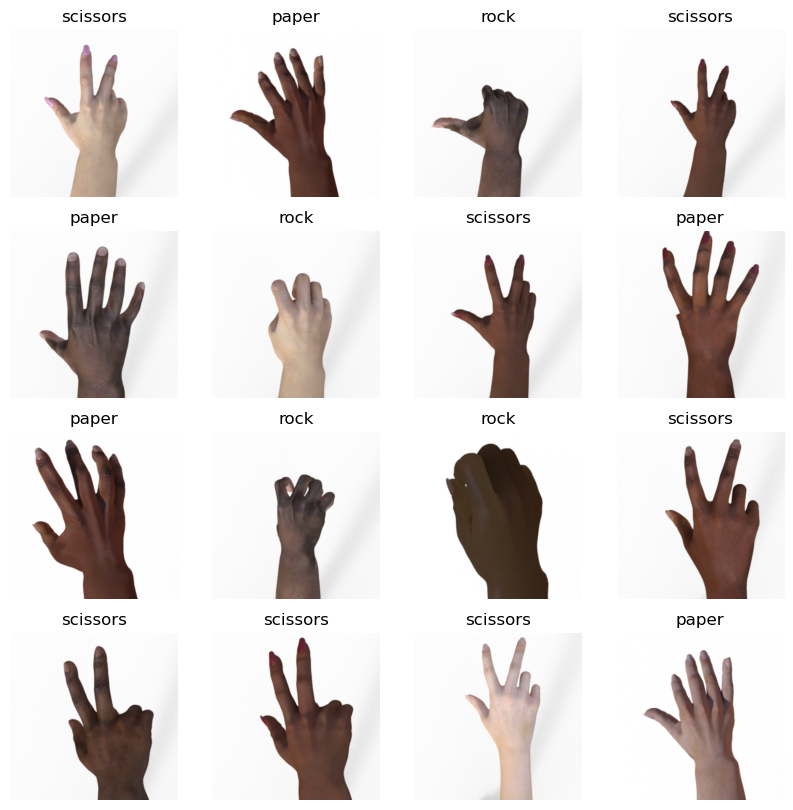

In [5]:
classes = ["rock", "paper", "scissors"]
nrows = 4
ncols = 4

plt.figure(figsize=(10, 10))
for i in range(1, nrows*ncols+1):
    random_class = random.choice(classes)
    random_path = os.path.join(data_dir, "train", "rps", random_class)
    random_image_path = random.choice(glob.glob(os.path.join(random_path, "*.png")))
    img = Image.open(random_image_path)
    plt.subplot(nrows, ncols, i)
    plt.imshow(img)
    plt.title(f'{random_class}')
    plt.axis(False)
    
    
    


In [6]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.4),
    v2.RandomRotation(degrees=30),
    v2.Resize((256,256)),
    v2.ToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5]*3, std=[0.5]*3),
    
]
)

test_transform = v2.Compose([
    v2.Resize((256,256)),
    v2.ToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5]*3, std=[0.5]*3), 
]
)

c:\Users\Global Lecturer\miniconda3\envs\mlenv\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [7]:
eval_data = ImageFolder(data_dir/"test"/"rps-test-set", transform=test_transform)
train_dataset = ImageFolder(data_dir/"train"/"rps", transform=train_transform)
test_dataset, validation_dataset = random_split(eval_data, [272, 100])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


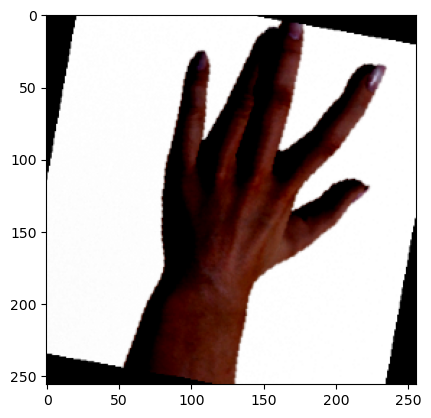

In [8]:
img, label = train_dataset[6]
plt.imshow(img.permute(1,2,0))

In [9]:
BATCHSIZE= 32
train_loader = DataLoader(dataset=train_dataset,batch_size=BATCHSIZE,      
    shuffle=True)
test_loader = DataLoader(dataset=test_dataset,batch_size=BATCHSIZE//2,      
    shuffle=False)
valid_loader = DataLoader(dataset=test_dataset,batch_size=BATCHSIZE//2,      
    shuffle=False)

In [10]:

class RPSNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)

        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32,  out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            )
        
        self.block3 = nn.Sequential(
                    nn.Conv2d(in_channels=64,  out_channels=64, kernel_size=3, padding=1),
                    nn.BatchNorm2d(64),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),
                    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
                    nn.BatchNorm2d(64),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),
                   )
        self.adaptive = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Linear(in_features=1024, out_features=100),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=100, out_features=num_classes)
        )
        
    def forward(self, input):
        x = self.block1(input)
        x = self.block2(x)
        x = self.block3(x)
        x = self.adaptive(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    

In [11]:
def init_weight(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_uniform(module.weight, mode="fan_in", nonlinearity="relu")
        if module.bias is not None:
            nn.init.constant_(module.bias, 0)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.constant_(module.weight, 1)
        nn.init.constant_(module.bias, 0)

In [12]:
def eval_model(model, dataloader, loss_func,  metrics, device):
    model.eval()
    metrics.reset()
    test_loss = 0.0
    with torch.inference_mode():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            y_logits = model(x)
            loss = loss_func(y_logits, y)
            test_loss += loss.item()
            y_pred= torch.argmax(y_logits, dim=1)
            metrics.update(y_pred, y)
        return test_loss/len(dataloader), metrics.compute()

    
    
def train_model(model, epochs, train_loader, test_loader, device, metrics, optimizer, loss_func):
    results = {
        "train_loss":[],
        "test_loss" : [],
        "train_acc":[],
        "test_acc": []
    }
    
    for epoch in range(epochs):
        model.train()
        metrics.reset()
        train_loss= 0.0
        for x, y in train_loader:
            x,y = x.to(device), y.to(device)
            y_logits = model(x)
            y_pred = torch.argmax(y_logits, dim=1)
            loss = loss_func(y_logits, y)
            metrics.update(y_pred, y)
            train_loss += loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss /= len(train_loader)
        train_acc = metrics.compute()
        test_loss, test_acc = eval_model(model=model, dataloader=test_loader, loss_func=loss_func, metrics=metrics, device=device)
        results["train_loss"].append(train_loss)
        results["test_loss"].append(test_loss)
        results["train_acc"].append(train_acc)
        results["test_acc"].append(test_acc)
        print(
            f'epoch: {epoch+1}/{epochs} '
            f"train loss: {train_loss} "
            f"test loss: {test_loss} "
            f"train acc: {train_acc} "
            f"test acc: {test_acc}"
        )
        
    return results

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = RPSNet(in_channels=3, num_classes=3).to(device)
model.apply(init_weight)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001)
metrics = MulticlassAccuracy(num_classes=3).to(device)

results = train_model(
    model=model, epochs=20, train_loader=train_loader, 
    test_loader=test_loader, device=device, metrics=metrics,
    optimizer=optimizer, loss_func=loss_func)

C:\Users\Global Lecturer\AppData\Local\Temp\ipykernel_3628\3196684825.py:3: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  nn.init.kaiming_uniform(module.weight, mode="fan_in", nonlinearity="relu")


epoch: 1/20 train loss: 1.328240156173706 test loss: 0.9152897561297697 train acc: 0.4015873074531555 test acc: 0.656924307346344
epoch: 2/20 train loss: 0.9228721261024475 test loss: 0.8745520185021793 train acc: 0.5603174567222595 test acc: 0.6570048332214355
epoch: 3/20 train loss: 0.7967005968093872 test loss: 0.8090446100515478 train acc: 0.6317460536956787 test acc: 0.6900161504745483
epoch: 4/20 train loss: 0.6589534282684326 test loss: 0.7308546480010537 train acc: 0.7214285731315613 test acc: 0.7154589295387268
epoch: 5/20 train loss: 0.5772433280944824 test loss: 0.6651567536241868 train acc: 0.7662698030471802 test acc: 0.7412238121032715
epoch: 6/20 train loss: 0.49525079131126404 test loss: 0.6129013615496018 train acc: 0.8035714030265808 test acc: 0.7596617937088013
epoch: 7/20 train loss: 0.4387854039669037 test loss: 0.5949208894196678 train acc: 0.8353174924850464 test acc: 0.774718165397644
epoch: 8/20 train loss: 0.3871651291847229 test loss: 0.5450712793013629 train

KeyboardInterrupt: 